# Accelerated Proximal Point Method (APPM) Example

This code tests the Accelerated Proximal Point Method which is the exact optimal method that 
reduces the fixed-point residual $||x - J_{\alpha A}x||$ with respect to the initial distance to the solution 
for a maximal monotone operator A. It was introduced in "Accelerated proximal point method for 
maximally monotone operators" by Donghwan Kim (2021). This method is equivalent to what 
later came to be known as the Optimized Halpern Method, which was studied in "On the 
Convergence Rate of the Halpern Iteration" by Felix Lieder (2021). The details of the 
equivalence can be found in Exercise 12.10 of Large-Scale Convex Optimization: 
Algorithms & Analyses via Monotone Operators by Ernest K. Ryu and Wotao Yin (2022).

## Import the required libraries

In [1]:
import pepflow as pf
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from itertools import combinations
from IPython.display import display, Math

## Define the operators

In [2]:
A = pf.MonotoneOperator(is_basis=True, tags=["A"])

## Write a function to return the PEPContext associated with APPM

In [3]:
def make_ctx_appm(
    ctx_name: str, N: int | sp.Integer, stepsize: pf.Parameter
) -> pf.PEPContext:
    ctx_appm = pf.PEPContext(ctx_name).set_as_current()
    x = pf.Vector(is_basis=True, tags=["x_0"])
    y = x.add_tag("y_0")
    A.set_zero_point("x_star")
    for i in range(N):
        x = A.resolvent(y, stepsize, tag=f"x_{i + 1}")
        y = (
            sp.S(i + 1) / sp.S(i + 2) * (sp.S(2) * x - y)
            + sp.S(1) / sp.S(i + 2) * ctx_appm["x_0"]
        ).add_tag(f"y_{i + 1}")

    return ctx_appm

## Numerical evidence of convergence of APPM

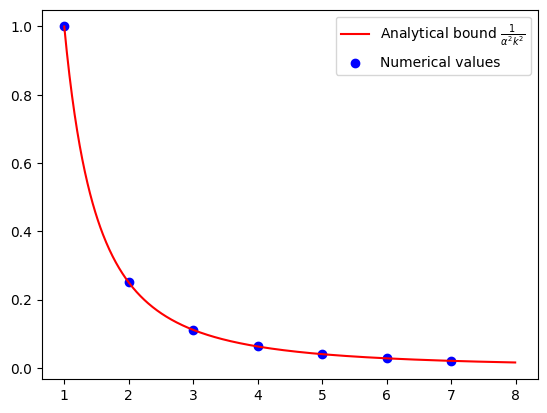

In [4]:
N = 8
alpha = pf.Parameter("alpha")
R = pf.Parameter("R")
alpha_value = 1
R_value = 1

ctx_plt = make_ctx_appm(ctx_name="ctx_plt", N=N, stepsize=alpha)
pb_plt = pf.PEPBuilder(ctx_plt)
pb_plt.add_initial_constraint(
    ((ctx_plt["x_0"] - ctx_plt["x_star"]) ** 2).le(R, name="initial_condition")
)

opt_values = []
for k in range(1, N):
    x_k = ctx_plt[f"x_{k}"]
    pb_plt.set_performance_metric(A(x_k) ** 2)
    result = pb_plt.solve(resolve_parameters={"alpha": alpha_value, "R": R_value})
    opt_values.append(result.opt_value)

iters = np.arange(1, N)
cont_iters = np.arange(1, N, 0.01)
plt.plot(
    cont_iters,
    1 / (alpha_value**2 * cont_iters**2),
    "r-",
    label="Analytical bound $\\frac{1}{\\alpha^2 k^2}$",
)
plt.scatter(iters, opt_values, color="blue", marker="o", label="Numerical values")
plt.legend()

## Verification of convergence of APPM

In [5]:
N = sp.S(4)
alpha_value = sp.S(1)
R_value = sp.S(1)

ctx_prf = make_ctx_appm(ctx_name="ctx_prf", N=N, stepsize=alpha)
pb_prf = pf.PEPBuilder(ctx_prf)
pb_prf.add_initial_constraint(
    ((ctx_prf["x_0"] - ctx_prf["x_star"]) ** 2).le(R, name="initial_condition")
)
pb_prf.set_performance_metric(A(ctx_prf[f"x_{N}"]) ** 2)

result = pb_prf.solve(resolve_parameters={"alpha": alpha_value, "R": R_value})
print(result.opt_value)

# Dual variables associated with the interpolations conditions of f with no relaxation
lamb_dense = result.get_scalar_constraint_dual_value_in_numpy(A)

0.06250301959936219


In [6]:
# pf.launch_primal_interactive(
#     pb_prf, ctx_prf, resolve_parameters={"alpha": alpha_value, "R": R_value}
# )

- It turns out for APPM no further relaxation is needed. Now we store the results.


In [7]:
# Dual variable associated with the initial condition
tau_sol = result.dual_var_manager.dual_value("initial_condition")
# Dual variable associated with the interpolations conditions of A
lamb_sol = result.get_scalar_constraint_dual_value_in_numpy(A)
# Dual variable associated with the Gram matrix G
S_sol = result.get_gram_dual_matrix()

### Verify closed form expression of $\lambda$

In [8]:
def tag_to_index(tag, N=N):
    """This is a function that takes in a tag of an iterate and returns its index.
    We index "x_star" as "N+1 where N is the last iterate.
    """
    # Split the string on "_" and get the index
    if (idx := tag.split("_")[1]).isdigit():
        return int(idx)
    elif idx == "star":
        return N + 1

- Print the values of $\lambda$ obtained from the solver

In [9]:
lamb_sol.pprint()

<IPython.core.display.Math object>

- Consider proper candidate of closed form expression of $\lambda$

In [10]:
def lamb(tag_i, tag_j, N=N):
    i = tag_to_index(tag_i)
    j = tag_to_index(tag_j)
    if j - 1 == i:
        if j == N + 1:
            return sp.S(2) / N  ## Between N and optimal
        else:
            return sp.S(2) * (sp.S(j) - sp.S(1)) * sp.S(j) / N**2  ## Consecutive
    return 0


lamb_cand = pf.pprint_labeled_matrix(
    lamb, lamb_sol.row_names, lamb_sol.col_names, return_matrix=True
)

<IPython.core.display.Math object>

- Check whether our candidate of $\lambda$ matches with solution

In [11]:
print(
    "Did we guess the right closed form of lambda?",
    np.allclose(lamb_cand, lamb_sol.matrix, atol=1e-3),
)

Did we guess the right closed form of lambda? True


### Closed form expression of $S$

In [12]:
S_sol.pprint()

<IPython.core.display.Math object>

In [13]:
ctx_prf.basis_vectors()

[y_0, x_star, A(x_1), A(x_2), A(x_3), A(x_4)]

In [14]:
x_0 = ctx_prf["x_0"]
x_N = ctx_prf[f"x_{N}"]
x_star = ctx_prf["x_star"]

S_guess = (A(x_N) - 1 / (alpha * N) * (x_0 - x_star)) ** 2

pm = pf.ExpressionManager(ctx_prf, resolve_parameters={"alpha": sp.S(1)})
S_guess_eval = pm.eval_scalar(S_guess).matrix
pf.pprint_labeled_matrix(S_guess_eval, S_sol.row_names, S_sol.col_names)

<IPython.core.display.Math object>

In [15]:
print(
    "Did we guess the right closed form of S?",
    np.allclose(S_guess_eval, S_sol.matrix, atol=1e-3),
)

Did we guess the right closed form of S? True


#### Verify symbolic calculation for fixed $N$

In [16]:
interpolation_scalar_sum = 0
for i in range(N + 2):
    for j in range(N + 2):
        xi = "x_star" if i == N + 1 else f"x_{i}"
        xj = "x_star" if j == N + 1 else f"x_{j}"
        if lamb(xi, xj) != 0:
            interpolation_scalar_sum += lamb(xi, xj) / alpha * A.interp_ineq(xi, xj)

interpolation_scalar_sum

0+1/4/alpha*⟨-(x_1-(x_2)),A(x_1)-A(x_2)⟩+3/4/alpha*⟨-(x_2-(x_3)),A(x_2)-A(x_3)⟩+3/2/alpha*⟨-(x_3-(x_4)),A(x_3)-A(x_4)⟩+1/2/alpha*⟨-(x_4-x_star),A(x_4)-A(x_star)⟩

In [17]:
RHS = interpolation_scalar_sum - S_guess
display(RHS)

0+1/4/alpha*⟨-(x_1-(x_2)),A(x_1)-A(x_2)⟩+3/4/alpha*⟨-(x_2-(x_3)),A(x_2)-A(x_3)⟩+3/2/alpha*⟨-(x_3-(x_4)),A(x_3)-A(x_4)⟩+1/2/alpha*⟨-(x_4-x_star),A(x_4)-A(x_star)⟩-|A(x_4)-1/alpha*4*(y_0-x_star)|^2

In [18]:
LHS = A(x_N) ** 2 - 1 / (alpha**2 * N**2) * (x_0 - x_star) ** 2
display(LHS)

|A(x_4)|^2-1/alpha**2*16*|y_0-x_star|^2

In [19]:
difference = LHS - RHS
display(difference)

|A(x_4)|^2-1/alpha**2*16*|y_0-x_star|^2-(0+1/4/alpha*⟨-(x_1-(x_2)),A(x_1)-A(x_2)⟩+3/4/alpha*⟨-(x_2-(x_3)),A(x_2)-A(x_3)⟩+3/2/alpha*⟨-(x_3-(x_4)),A(x_3)-A(x_4)⟩+1/2/alpha*⟨-(x_4-x_star),A(x_4)-A(x_star)⟩-|A(x_4)-1/alpha*4*(y_0-x_star)|^2)

In [20]:
pf.pprint_str(
    difference.repr_by_basis(
        ctx_prf, sympy_mode=True, resolve_parameters={"alpha": sp.S("alpha")}
    )
)

<IPython.core.display.Math object>

\begin{align*}
    \| \tilde{\mathbb{A}}(x^N) \|^2 - \frac{\| x^0 - x^\star \|^2}{\alpha^2 N^2}
    &= -\sum_{k=1}^{N-1} \frac{2k(k+1)}{\alpha^2 N^2} \langle \tilde{\mathbb{A}}(x^{k+1}) - \tilde{\mathbb{A}}(x^k), x^{k+1} - x^k \rangle \\&\quad 
    - \frac{2}{\alpha N} \langle \tilde{\mathbb{A}}(x^{N}), x^{N} - x^\star \rangle \\&\quad 
    - \| \tilde{\mathbb{A}}(x^N) - \frac{1}{\alpha N} ( x^0 - x^\star)  \| ^2.
\end{align*}

---

In [21]:
special_vectors = ctx_prf.basis_vectors()

y_0 = ctx_prf[f"y_{0}"]
x = [y_0] + [ctx_prf[f"x_{i}"] for i in range(1, N + 1)]
special_vectors += x[1:]

# Add any two difference between special vectors as new special vectors
for i, j in combinations(range(len(special_vectors)), 2):
    diff = special_vectors[i] - special_vectors[j]
    special_vectors.append(diff)

In [22]:
print(special_vectors)

[y_0, x_star, A(x_1), A(x_2), A(x_3), A(x_4), x_1, x_2, x_3, x_4, y_0-x_star, y_0-A(x_1), y_0-A(x_2), y_0-A(x_3), y_0-A(x_4), y_0-(x_1), y_0-(x_2), y_0-(x_3), y_0-(x_4), x_star-A(x_1), x_star-A(x_2), x_star-A(x_3), x_star-A(x_4), x_star-(x_1), x_star-(x_2), x_star-(x_3), x_star-(x_4), A(x_1)-A(x_2), A(x_1)-A(x_3), A(x_1)-A(x_4), A(x_1)-(x_1), A(x_1)-(x_2), A(x_1)-(x_3), A(x_1)-(x_4), A(x_2)-A(x_3), A(x_2)-A(x_4), A(x_2)-(x_1), A(x_2)-(x_2), A(x_2)-(x_3), A(x_2)-(x_4), A(x_3)-A(x_4), A(x_3)-(x_1), A(x_3)-(x_2), A(x_3)-(x_3), A(x_3)-(x_4), A(x_4)-(x_1), A(x_4)-(x_2), A(x_4)-(x_3), A(x_4)-(x_4), x_1-(x_2), x_1-(x_3), x_1-(x_4), x_2-(x_3), x_2-(x_4), x_3-(x_4)]


## Identify the vectors composing the Lyapunov function

Compute the sum of active inequalities up to k-th iteration

In [23]:
lyap = [pf.Scalar.zero()]
partial_sum = 0
for j in np.arange(1, N):
    partial_sum += lamb(f"x_{j}", f"x_{j + 1}") * A.interp_ineq(f"x_{j}", f"x_{j + 1}")
    lyap.append(partial_sum)

Check that the ranks of V_k are constantly 2

In [24]:
for k in range(len(lyap)):
    lyap_numeric_k = pm.eval_scalar(lyap[k]).inner_prod_coords.astype(float)
    print(f"Rank of lyap[{k}]: {np.linalg.matrix_rank(lyap_numeric_k, tol=1e-6)}")

Rank of lyap[0]: 0
Rank of lyap[1]: 2
Rank of lyap[2]: 2
Rank of lyap[3]: 2


In [25]:
# Collect the vectors in the column space of matrix A from a given list


def vectors_in_column_space(V, vectors, rtol=1e-7, atol=1e-12):
    """
    V: quadratic form of vectors that corresponds to a matrix
    vectors: list of vectors
    returns: list of vectors that are in col(V) up to numerical tolerance
    """
    V_coords = np.asarray(pm.eval_scalar(V).inner_prod_coords, dtype=float)

    # SVD of A
    U, S, _ = np.linalg.svd(V_coords, full_matrices=False)

    # numerical rank
    tol = atol + rtol * S[0]
    rank = np.sum(S > tol)

    # basis for column space
    Uc = U[:, :rank]

    results = []
    for v in vectors:
        v_coords = np.asarray(pm.eval_vector(v).coords, dtype=float)
        proj = Uc @ (Uc.T @ v_coords)
        residual = np.linalg.norm(v_coords - proj)
        if residual <= atol + rtol * np.linalg.norm(v_coords):
            results.append(v)
    return results

#### Extract the special vectors representing lyap[k] = V_{k+1}

In [26]:
for k in range(len(lyap)):
    print(f"V_{k + 1}:", vectors_in_column_space(lyap[k], special_vectors))

V_1: []
V_2: [A(x_1), A(x_2), y_0-(x_1), y_0-(x_2), A(x_1)-A(x_2), x_1-(x_2)]
V_3: [A(x_3), y_0-(x_3)]
V_4: [A(x_4), y_0-(x_4)]


---

### Numerically guessing the coefficients of $V_k$
- V_{k} is represented using A(x_{k}) and y_0 - x_{k}
- Let's find the corresponding coefficients

In [27]:
def decompose_rank2_symmetric(pm, S, v, w, *, sym_tol=1e-10):
    S = np.asarray(pm.eval_scalar(S).inner_prod_coords, dtype=float)
    v = np.asarray(pm.eval_vector(v).coords, dtype=float).ravel()
    w = np.asarray(pm.eval_vector(w).coords, dtype=float).ravel()

    n = S.shape[0]
    if S.shape != (n, n):
        raise ValueError("S must be square.")
    if v.shape != (n,) or w.shape != (n,):
        raise ValueError("v,w must have shape (n,).")

    if np.linalg.norm(S - S.T, ord="fro") > sym_tol * max(
        1.0, np.linalg.norm(S, ord="fro")
    ):
        raise ValueError("S is not symmetric within tolerance.")

    # Solve over all entries: vec(S) = a vec(vv^T) + b vec(vw^T+wv^T) + c vec(ww^T)
    X = np.stack(
        [
            np.outer(v, v).reshape(-1),
            (np.outer(v, w) + np.outer(w, v)).reshape(-1),
            np.outer(w, w).reshape(-1),
        ],
        axis=1,
    )
    y = S.reshape(-1)

    (a, b, c), *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(a), float(b), float(c)

In [28]:
precision = 3

$ V_{1} = \frac{1}{2} * ||A(x_{2})||^2 - \frac{1}{4} * \langle A(x_{2}), y_0 - x_{2} \rangle $

In [29]:
lyap_0_coeff = decompose_rank2_symmetric(pm, lyap[0], A(x[2]), y_0 - x[2])
print(np.round(lyap_0_coeff, precision))

[0. 0. 0.]


$ V_{2} = \frac{9}{8} * ||A(x_{3})||^2 - \frac{3}{8} * \langle A(x_{3}), y_0 - x_{3} \rangle $

In [30]:
lyap_1_coeff = decompose_rank2_symmetric(pm, lyap[1], A(x[3]), y_0 - x[3])
print(np.round(lyap_1_coeff, precision))

[ 0.045 -0.045  0.045]


$ V_{3} = 2 * ||A(x_{4})||^2 - \frac{1}{2} * \langle A(x_{3}), y_0 - x_{3} \rangle $

In [31]:
lyap_2_coeff = decompose_rank2_symmetric(pm, lyap[2], A(x[4]), y_0 - x[4])
print(np.round(lyap_2_coeff, precision))

[ 0.061 -0.061  0.061]


$$ V_{k} = \frac{1}{8} \Big(k^2 ||A(x_{k})||^2 - k \langle A(x_{k}), y_0 - x_{k} \rangle \Big) $$

---

### Finding the coefficient of Lyapunov function (symbolic)

In [32]:
ctx_appm_lyap = pf.PEPContext("appm_lyap_finder").set_as_current()

In [33]:
y_0 = pf.Vector(is_basis=True, tags=["y_0"])
y_k = pf.Vector(is_basis=True, tags=["y_k"])
Ax_k1 = pf.Vector(is_basis=True, tags=["Ax_{k1}"])
Ax_k2 = pf.Vector(is_basis=True, tags=["Ax_{k2}"])
k = pf.Parameter("k")
alpha = 1

y_k1 = 1 / (k + 2) * y_0 + (k + 1) / (k + 2) * (y_k - 2 * Ax_k1)

a_k = pf.Parameter("a_k")
a_k1 = pf.Parameter("a_k1")
b_k = pf.Parameter("b_k")
b_k1 = pf.Parameter("b_k1")
N = pf.Parameter("N")

V_k = a_k * Ax_k1 * Ax_k1 + b_k * (y_0 - y_k + Ax_k1) * Ax_k1
V_k1 = a_k1 * Ax_k2 * Ax_k2 + b_k1 * (y_0 - y_k1 + Ax_k2) * Ax_k2

diff = (
    V_k
    - V_k1
    - 2 * (k + 1) * (k + 2) / N**2 * (Ax_k1 - Ax_k2) * (y_k - y_k1 - Ax_k1 + Ax_k2)
)
diff

⟨a_k*Ax_{k1},Ax_{k1}⟩+⟨b_k*(y_0-y_k+Ax_{k1}),Ax_{k1}⟩-(⟨a_k1*Ax_{k2},Ax_{k2}⟩+⟨b_k1*(y_0-(1/(k+2)*y_0+(k+1)/(k+2)*(y_k-2*Ax_{k1}))+Ax_{k2}),Ax_{k2}⟩)-⟨2*(k+1)*(k+2)/N**2*(Ax_{k1}-Ax_{k2}),y_k-(1/(k+2)*y_0+(k+1)/(k+2)*(y_k-2*Ax_{k1}))-Ax_{k1}+Ax_{k2}⟩

In [34]:
basis = ctx_appm_lyap.basis_vectors()
row_index = [str(v) for v in basis]
row_index

['y_0', 'y_k', 'Ax_{k1}', 'Ax_{k2}']

In [35]:
pm_lyap = pf.ExpressionManager(
    ctx_appm_lyap,
    resolve_parameters={
        "a_k": sp.Symbol("a_k"),
        "a_k1": sp.Symbol("a_k1"),
        "b_k": sp.Symbol("b_k"),
        "b_k1": sp.Symbol("b_k1"),
        "N": sp.Symbol("N"),
        "k": sp.Symbol("k"),
    },
)

diff_matrix = pm_lyap.eval_scalar(diff).inner_prod_coords
pf.pprint_labeled_matrix(diff_matrix, row_index, row_index, precision=None)

<IPython.core.display.Math object>

In [36]:
import sympy as sp

diff_matrix_sympify = sp.Matrix(diff_matrix)

a_k, a_k1, b_k, b_k1, N, k = sp.symbols("a_k a_k1 b_k b_k1 N k")

unknowns = (a_k, a_k1, b_k, b_k1)

eqs = list(diff_matrix_sympify)
eqs = [e for e in eqs]

sol = sp.linsolve(eqs, unknowns)
sol_simplify = sp.factor(sp.factor(sp.nsimplify(sol)))

print("Solutions:")
sol_dict = dict(zip(unknowns, next(iter(sol_simplify))))
display(Math(sp.latex(sol_dict)))

Solutions:


<IPython.core.display.Math object>

Double check we found the right solution

In [37]:
if sol:
    print("\nVerification:")
    display(sp.simplify(diff_matrix_sympify.subs(sol_dict)))


Verification:


Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])